# Interpretable and Trustworthy Early Sepsis Prediction from Multimodal ICU Time-Series

## Objective
This project investigates whether static patient information and temporally summarized ICU measurements can support early sepsis prediction while producing clinically meaningful, transparent, and trustworthy explanations. The focus is not only predictive performance, but also whether the resulting models remain interpretable, calibrated, and robust under realistic leakage-aware evaluation.

## Research Question
How can early sepsis prediction models based on static and temporal ICU data be designed so that they remain both predictive and clinically interpretable under realistic evaluation settings?

## Exploratory Research Questions

This pipeline is designed as an exploratory investigation into interpretable and trustworthy early sepsis prediction. Rather than testing a single pre-specified hypothesis, the goal is to identify empirically grounded research questions about the relationship between temporal clinical signal, predictive performance, and explanation quality.

1. **Interpretability and clinical meaning:**: Which physiological variables and temporal patterns are consistently identified as important by the models, and do these explanations align with clinically plausible indicators of sepsis risk?
2. **Explanation consistency and trustworthiness**: How stable are the learned explanations across data cohorts, model families, and evaluation settings?
3. **Temporal signal contribution**: To what extent do temporal trajectory features improve prediction beyond static patient characteristics alone?
4. **Performance under realistic imbalance**: Under severe class imbalance, how well can models detect early sepsis without generating excessive false positives?
5. **Cross-cohort robustness**: How much does model performance and explanation structure change when evaluated across different clinical cohorts?

## Pipeline Overview

Raw ICU Data → Leakage-Aware Temporal Sampling → Clinically Interpretable Feature Engineering → Tabular Modeling → Evaluation of Prediction, Calibration, and Explanation Consistency

In [1]:
import os
import glob
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

from sklearn.model_selection import train_test_split, GroupShuffleSplit, ParameterGrid
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, brier_score_loss, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42

DATA_DIR_A = "physionet.org/files/challenge-2019/1.0.0/training/training_setA"
DATA_DIR_B = "physionet.org/files/challenge-2019/1.0.0/training/training_setB"

OBS_WINDOW = 12       # hours used as input
PRED_HORIZON = 6      # predict sepsis in next 6h
STEP_HOURS = 1        # rolling window step
MIN_HISTORY = 6       # minimum observed hours required

A temporally summarized tabular representation is used in order to preserve interpretability, handle irregular sampling, and support clinically inspectable explanations.

## Data loading

In [2]:
def get_patient_files(data_dir: str) -> List[str]:
    return sorted(glob.glob(os.path.join(data_dir, "*.psv")))

files_a = get_patient_files(DATA_DIR_A)
files_b = get_patient_files(DATA_DIR_B)

print(f"Set A files: {len(files_a)}")
print(f"Set B files: {len(files_b)}")

def read_patient_file(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path, sep="|")
    patient_id = os.path.basename(file_path).replace(".psv", "")
    df["patient_id"] = patient_id
    return df

example_df = read_patient_file(files_a[0])
example_df.head()

Set A files: 20320
Set B files: 19989


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,NaN,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001


The raw data consist of irregularly sampled multivariate ICU time-series with substantial variable-specific missingness, making direct sequential modeling difficult without additional assumptions.

## Basic sanity checks

(54, 42)
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'patient_id']
SepsisLabel
0    54
Name: count, dtype: int64


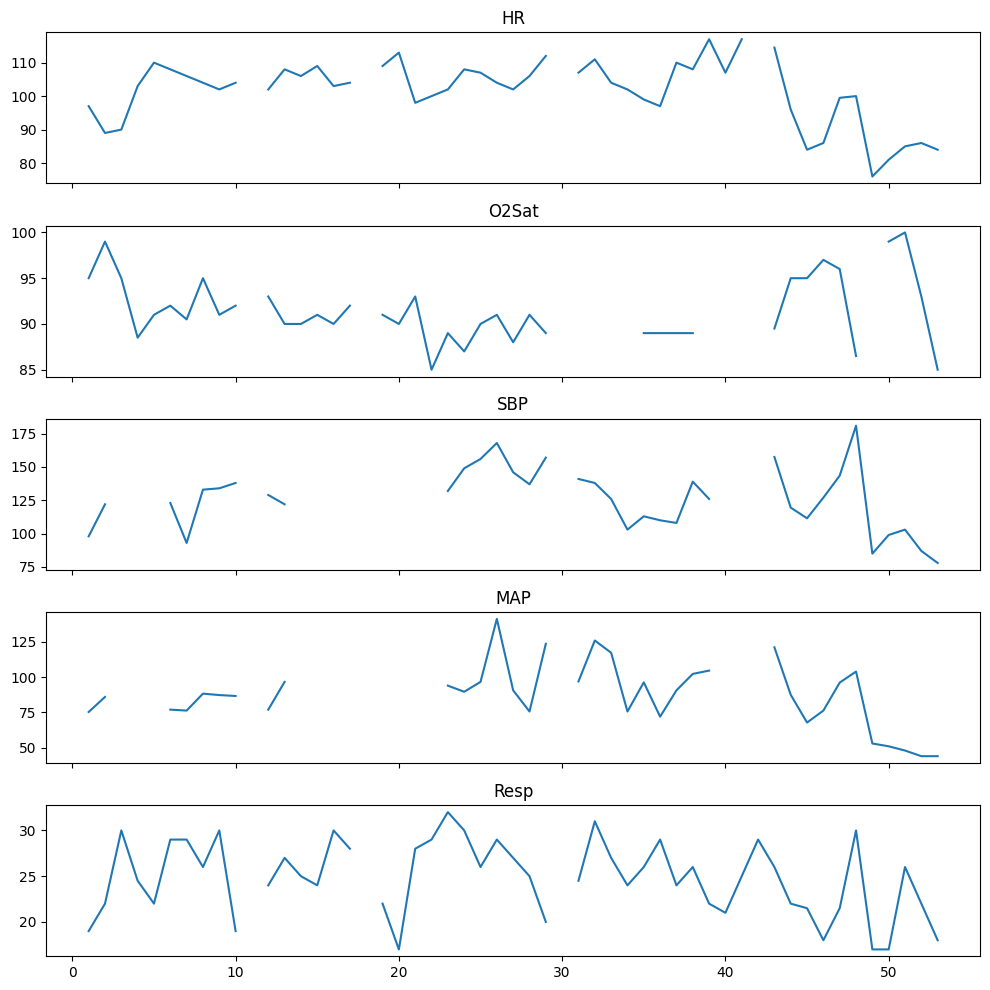

In [3]:
print(example_df.shape)
print(example_df.columns.tolist())
print(example_df["SepsisLabel"].value_counts(dropna=False))
example_df.isna().mean().sort_values(ascending=False).head(15)

# Plot
cols_to_plot = ["HR", "O2Sat", "SBP", "MAP", "Resp"]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(10, 10), sharex=True)
for ax, col in zip(axes, cols_to_plot):
    if col in example_df.columns:
        ax.plot(example_df.index, example_df[col])
        ax.set_title(col)
plt.tight_layout()
plt.show()


These initial checks confirm that the raw ICU trajectories are sparse, irregular, and heterogeneous across variables, motivating a modeling strategy that summarizes temporal behavior into clinically interpretable descriptors.

## Dataset Characteristics

The ICU time-series exhibit strong irregularity and substantial missingness across variables. Measurements are not recorded uniformly over time, and clinical variables differ considerably in sampling frequency. Rather than imposing a fully sequential deep learning formulation, this project adopts a temporally summarized representation that preserves clinically interpretable trends while remaining robust to sparse observation patterns.

In [4]:
def get_sepsis_onset_hour(df: pd.DataFrame) -> Optional[int]:
    positive_idx = df.index[df["SepsisLabel"] == 1].tolist()
    if len(positive_idx) == 0:
        return None
    return int(min(positive_idx))

def label_future_sepsis(df: pd.DataFrame, t: int, horizon: int) -> Optional[int]:
    onset = get_sepsis_onset_hour(df)

    # If patient already septic by or before prediction time, exclude
    if onset is not None and onset <= t:
        return None

    # Positive if onset occurs within future horizon
    if onset is not None and (t < onset <= t + horizon):
        return 1

    return 0

Labels are defined prospectively: only patients not yet septic at the prediction time are considered, and positives correspond to sepsis onset within the future prediction horizon.

## Temporal Sample generation

Each patient contributes multiple prediction points over time. For every valid prediction time, the model only uses information available up to that point, ensuring a prospective and leakage-aware setup. This rolling-window design allows temporal evolution to be represented while preserving explicit control over which measurements influence each prediction.

In [5]:
STATIC_COLS = ["Age", "Gender", "Unit1", "Unit2", "HospAdmTime"]

TEMPORAL_COLS = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp",
    "EtCO2", "BaseExcess", "HCO3", "FiO2", "pH", "PaCO2",
    "SaO2", "AST", "BUN", "Alkalinephos", "Calcium", "Chloride",
    "Creatinine", "Bilirubin_direct", "Glucose", "Lactate",
    "Magnesium", "Phosphate", "Potassium", "Bilirubin_total",
    "TroponinI", "Hct", "Hgb", "PTT", "WBC", "Platelets"
]

def generate_prediction_times(n_hours: int, min_history: int, step: int = 1) -> List[int]:
    return list(range(min_history - 1, n_hours - 1, step))

## Feature Construction

To model irregular ICU trajectories while preserving interpretability, each patient’s recent history is transformed into a set of clinically inspectable temporal descriptors. For each variable, the pipeline captures level, variability, extremes, recency, directional change, and observation density.

For each variable (e.g., heart rate, blood pressure), we compute:

- level (mean, last observed value)
- variability (standard deviation)
- extremes (minimum, maximum)
- direction of change (delta, slope)
- data availability (measurement count, missing fraction)

This representation is intentionally designed to make model reasoning easier to inspect than black-box sequence encodings, while still retaining clinically relevant aspects of temporal behavior.

In [6]:
# Static features
def extract_static_features(df_hist: pd.DataFrame) -> Dict[str, float]:
    feats = {}
    first_row = df_hist.iloc[0]

    for col in STATIC_COLS:
        feats[f"static__{col}"] = first_row[col] if col in df_hist.columns else np.nan

    return feats

# Temporal summary features
def compute_slope(values: pd.Series) -> float:
    s = values.dropna()
    if len(s) < 2:
        return np.nan

    x = s.index.to_numpy()
    y = s.to_numpy()

    return np.polyfit(x, y, 1)[0]

def extract_temporal_features(
    df_hist: pd.DataFrame,
    temporal_cols: List[str]
) -> Dict[str, float]:
    feats = {}

    for col in temporal_cols:
        if col not in df_hist.columns:
            continue

        s = df_hist[col]
        non_null = s.dropna()

        feats[f"temp__{col}__mean"] = s.mean()
        feats[f"temp__{col}__std"] = s.std()
        feats[f"temp__{col}__min"] = s.min()
        feats[f"temp__{col}__max"] = s.max()
        feats[f"temp__{col}__range"] = s.max() - s.min() if len(non_null) > 0 else np.nan

        feats[f"temp__{col}__first"] = non_null.iloc[0] if len(non_null) > 0 else np.nan
        feats[f"temp__{col}__last"] = non_null.iloc[-1] if len(non_null) > 0 else np.nan
        feats[f"temp__{col}__delta"] = (
            non_null.iloc[-1] - non_null.iloc[0] if len(non_null) >= 2 else np.nan
        )
        feats[f"temp__{col}__slope"] = compute_slope(s)
        feats[f"temp__{col}__missing_frac"] = s.isna().mean()
        feats[f"temp__{col}__count"] = float(s.notna().sum())

    return feats

# Clinical abnormality counts
def extract_abnormality_features(df_hist: pd.DataFrame) -> Dict[str, float]:
    feats = {}

    if "HR" in df_hist.columns:
        feats["abn__HR_high_count"] = (df_hist["HR"] > 100).sum()
    if "Temp" in df_hist.columns:
        feats["abn__Temp_high_count"] = (df_hist["Temp"] > 38.0).sum()
    if "Resp" in df_hist.columns:
        feats["abn__Resp_high_count"] = (df_hist["Resp"] > 22).sum()
    if "WBC" in df_hist.columns:
        feats["abn__WBC_abnormal_count"] = ((df_hist["WBC"] > 12) | (df_hist["WBC"] < 4)).sum()

    return feats

In addition to generic temporal summaries, the pipeline includes simple abnormality counts based on clinically motivated thresholds for selected physiological variables, helping connect statistical patterns to clinically recognizable risk indicators.

> Note: Due to extreme class imbalance (~1% positive rate), model performance is evaluated using AUROC, AUPRC, and threshold-based metrics. Undersampling is applied only to the training set.

## Modeling

Each row in the modeling table represents a patient state at a given prediction time, combining static information with interpretable summaries of recent temporal behavior.

In [7]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors

APPLY_DOWNSAMPLING = True
NEG_POS_RATIO = 10

def cluster_undersample(df: pd.DataFrame, target_col: str = "target",
                        n_clusters: int = 100, ratio: float = 10.0,
                        random_state: int = 42) -> pd.DataFrame:
    """
    Pragmatic undersampling of the majority class for imbalanced training data.

    Procedure:
    1. Separate majority-class and minority-class samples.
    2. Cluster majority-class samples in feature space.
    3. Within each cluster, retain samples closest to the minority-class centroid.
    4. Return a reduced dataset with an approximately fixed neg:pos ratio.

    This is used only during training to support stable fitting under severe
    class imbalance. Validation and test sets remain untouched.
    """
    pos_df = df[df[target_col] == 1].copy()
    neg_df = df[df[target_col] == 0].copy()

    n_pos = len(pos_df)
    n_neg_target = int(n_pos * ratio)

    if len(neg_df) <= n_neg_target:
        return pd.concat([pos_df, neg_df], ignore_index=True)

    meta_cols = ["patient_id", "prediction_time", "target", "cohort"]
    feature_cols = [c for c in neg_df.columns if c not in meta_cols]

    neg_features = neg_df[feature_cols].fillna(0).values
    pos_features = pos_df[feature_cols].fillna(0).values

    actual_k = min(n_clusters, len(neg_df) // 10, n_neg_target)
    actual_k = max(actual_k, 2)

    km = MiniBatchKMeans(n_clusters=actual_k, random_state=random_state, batch_size=1024)
    neg_labels = km.fit_predict(neg_features)

    pos_centroid = pos_features.mean(axis=0).reshape(1, -1)

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(pos_centroid)
    distances, _ = nn.kneighbors(neg_features)
    neg_df = neg_df.copy()
    neg_df["__dist__"] = distances.ravel()
    neg_df["__cluster__"] = neg_labels

    samples_per_cluster = max(1, n_neg_target // actual_k)
    kept = []
    for cl in range(actual_k):
        cluster_rows = neg_df[neg_df["__cluster__"] == cl]
        n_take = min(samples_per_cluster, len(cluster_rows))
        kept.append(cluster_rows.nsmallest(n_take, "__dist__"))

    neg_sampled = pd.concat(kept, ignore_index=True)
    if len(neg_sampled) > n_neg_target:
        neg_sampled = neg_sampled.nsmallest(n_neg_target, "__dist__")

    neg_sampled = neg_sampled.drop(columns=["__dist__", "__cluster__"])
    result = pd.concat([pos_df, neg_sampled], ignore_index=True).sample(frac=1, random_state=random_state).reset_index(drop=True)

    print(f"  Downsampling: {len(neg_df)} neg -> {len(neg_sampled)} neg | {n_pos} pos | ratio={len(neg_sampled)/max(n_pos,1):.1f}:1")
    return result

Because early sepsis onset is rare, the training data exhibit substantial class imbalance. To support stable model fitting while preserving representative negative cases, the pipeline uses a pragmatic undersampling strategy during training. Final evaluation is still performed on untouched validation and test sets.

In [8]:
# Full-sample extractor
def build_sample_from_time(df: pd.DataFrame, t: int, horizon: int) -> Optional[Dict]:
    y = label_future_sepsis(df, t, horizon)
    if y is None:
        return None

    df_hist = df.iloc[max(0, t - OBS_WINDOW + 1):t + 1].copy()
    if len(df_hist) < MIN_HISTORY:
        return None

    sample = {
        "patient_id": df_hist["patient_id"].iloc[0],
        "prediction_time": t,
        "target": y
    }

    sample.update(extract_static_features(df_hist))
    sample.update(extract_temporal_features(df_hist, TEMPORAL_COLS))
    sample.update(extract_abnormality_features(df_hist))

    return sample

# Incremental dataset builder with resume

def build_dataset_incremental(
    file_list,
    cohort_name,
    save_path,
    save_every=200
):
    """
    Incrementally builds a dataset and resumes from an existing parquet file.

    Parameters
    ----------
    file_list : list
        List of raw patient file paths.
    cohort_name : str
        Cohort label, e.g. "A" or "B".
    save_path : str
        Parquet file where progress is saved.
    save_every : int
        Save checkpoint every N newly processed patients.

    Returns
    -------
    pd.DataFrame
        Final dataset for this cohort.
    """

    # Load previous progress if available
    if os.path.exists(save_path):
        existing_df = pd.read_parquet(save_path)
        processed_ids = set(existing_df["patient_id"].astype(str).unique())
        rows = existing_df.to_dict("records")
    else:
        existing_df = None
        processed_ids = set()
        rows = []

    newly_processed = 0
    total_files = len(file_list)

    for i, file_path in enumerate(file_list):
        patient_id = os.path.basename(file_path).replace(".psv", "")

        # Skip patients already processed
        if patient_id in processed_ids:
            continue

        df = read_patient_file(file_path)
        df["cohort"] = cohort_name

        prediction_times = generate_prediction_times(
            n_hours=len(df),
            min_history=MIN_HISTORY,
            step=STEP_HOURS
        )

        for t in prediction_times:
            row = build_sample_from_time(df, t=t, horizon=PRED_HORIZON)
            if row is not None:
                row["cohort"] = cohort_name
                rows.append(row)

        processed_ids.add(patient_id)
        newly_processed += 1

        # Save checkpoint every N newly processed patients
        if save_every is not None and newly_processed % save_every == 0:
            temp_df = pd.DataFrame(rows)
            temp_df.to_parquet(save_path, index=False)

    final_df = pd.DataFrame(rows)
    final_df.to_parquet(save_path, index=False)

    return final_df

In [9]:
MAX_FILES = 5000

SAVE_PATH_A = f"dataset_a_{MAX_FILES}_full.parquet"
SAVE_PATH_B = f"dataset_b_{MAX_FILES}_full.parquet"
SAVE_PATH_ALL = f"data_merged_{MAX_FILES}_full.parquet"

files_a_subset = files_a[:MAX_FILES]
files_b_subset = files_b[:MAX_FILES]

if os.path.exists(SAVE_PATH_ALL):
    dataset_a = pd.read_parquet(SAVE_PATH_A)
    dataset_b = pd.read_parquet(SAVE_PATH_B)
    data = pd.read_parquet(SAVE_PATH_ALL)
else:
    dataset_a = build_dataset_incremental(
        file_list=files_a_subset,
        cohort_name="A",
        save_path=SAVE_PATH_A,
        save_every=200
    )
    dataset_a.to_parquet(SAVE_PATH_A, index=False)

    dataset_b = build_dataset_incremental(
        file_list=files_b_subset,
        cohort_name="B",
        save_path=SAVE_PATH_B,
        save_every=200
    )
    dataset_b.to_parquet(SAVE_PATH_B, index=False)

    data = pd.concat([dataset_a, dataset_b], ignore_index=True)
    data.to_parquet(SAVE_PATH_ALL, index=False)    

data.head()

,patient_id,prediction_time,target,static__Age,static__Gender,static__Unit1,static__Unit2,static__HospAdmTime,temp__HR__mean,temp__HR__std,temp__HR__min,temp__HR__max,temp__HR__range,temp__HR__first,temp__HR__last,temp__HR__delta,temp__HR__slope,temp__HR__missing_frac,temp__HR__count,temp__O2Sat__mean,temp__O2Sat__std,temp__O2Sat__min,temp__O2Sat__max,temp__O2Sat__range,temp__O2Sat__first,temp__O2Sat__last,temp__O2Sat__delta,temp__O2Sat__slope,temp__O2Sat__missing_frac,temp__O2Sat__count,temp__Temp__mean,temp__Temp__std,temp__Temp__min,temp__Temp__max,temp__Temp__range,temp__Temp__first,temp__Temp__last,temp__Temp__delta,temp__Temp__slope,temp__Temp__missing_frac,temp__Temp__count,temp__SBP__mean,temp__SBP__std,temp__SBP__min,temp__SBP__max,temp__SBP__range,temp__SBP__first,temp__SBP__last,temp__SBP__delta,temp__SBP__slope,temp__SBP__missing_frac,temp__SBP__count,temp__MAP__mean,temp__MAP__std,temp__MAP__min,temp__MAP__max,temp__MAP__range,temp__MAP__first,temp__MAP__last,temp__MAP__delta,temp__MAP__slope,temp__MAP__missing_frac,temp__MAP__count,temp__DBP__mean,temp__DBP__std,temp__DBP__min,temp__DBP__max,temp__DBP__range,temp__DBP__first,temp__DBP__last,temp__DBP__delta,temp__DBP__slope,temp__DBP__missing_frac,temp__DBP__count,temp__Resp__mean,temp__Resp__std,temp__Resp__min,temp__Resp__max,temp__Resp__range,temp__Resp__first,temp__Resp__last,temp__Resp__delta,temp__Resp__slope,temp__Resp__missing_frac,temp__Resp__count,temp__EtCO2__mean,temp__EtCO2__std,temp__EtCO2__min,temp__EtCO2__max,temp__EtCO2__range,temp__EtCO2__first,temp__EtCO2__last,temp__EtCO2__delta,temp__EtCO2__slope,temp__EtCO2__missing_frac,temp__EtCO2__count,temp__BaseExcess__mean,temp__BaseExcess__std,temp__BaseExcess__min,temp__BaseExcess__max,...,temp__Phosphate__range,temp__Phosphate__first,temp__Phosphate__last,temp__Phosphate__delta,temp__Phosphate__slope,temp__Phosphate__missing_frac,temp__Phosphate__count,temp__Potassium__mean,temp__Potassium__std,temp__Potassium__min,temp__Potassium__max,temp__Potassium__range,temp__Potassium__first,temp__Potassium__last,temp__Potassium__delta,temp__Potassium__slope,temp__Potassium__missing_frac,temp__Potassium__count,temp__Bilirubin_total__mean,temp__Bilirubin_total__std,temp__Bilirubin_total__min,temp__Bilirubin_total__max,temp__Bilirubin_total__range,temp__Bilirubin_total__first,temp__Bilirubin_total__last,temp__Bilirubin_total__delta,temp__Bilirubin_total__slope,temp__Bilirubin_total__missing_frac,temp__Bilirubin_total__count,temp__TroponinI__mean,temp__TroponinI__std,temp__TroponinI__min,temp__TroponinI__max,temp__TroponinI__range,temp__TroponinI__first,temp__TroponinI__last,temp__TroponinI__delta,temp__TroponinI__slope,temp__TroponinI__missing_frac,temp__TroponinI__count,temp__Hct__mean,temp__Hct__std,temp__Hct__min,temp__Hct__max,temp__Hct__range,temp__Hct__first,temp__Hct__last,temp__Hct__delta,temp__Hct__slope,temp__Hct__missing_frac,temp__Hct__count,temp__Hgb__mean,temp__Hgb__std,temp__Hgb__min,temp__Hgb__max,temp__Hgb__range,temp__Hgb__first,temp__Hgb__last,temp__Hgb__delta,temp__Hgb__slope,temp__Hgb__missing_frac,temp__Hgb__count,temp__PTT__mean,temp__PTT__std,temp__PTT__min,temp__PTT__max,temp__PTT__range,temp__PTT__first,temp__PTT__last,temp__PTT__delta,temp__PTT__slope,temp__PTT__missing_frac,temp__PTT__count,temp__WBC__mean,temp__WBC__std,temp__WBC__min,temp__WBC__max,temp__WBC__range,temp__WBC__first,temp__WBC__last,temp__WBC__delta,temp__WBC__slope,temp__WBC__missing_frac,temp__WBC__count,temp__Platelets__mean,temp__Platelets__std,temp__Platelets__min,temp__Platelets__max,temp__Platelets__range,temp__Platelets__first,temp__Platelets__last,temp__Platelets__delta,temp__Platelets__slope,temp__Platelets__missing_frac,temp__Platelets__count,abn__HR_high_count,abn__Temp_high_count,abn__Resp_high_count,abn__WBC_abnormal_count,cohort
0,p000001,5,0,83.14,0,NaN,NaN,-0.03,97.800000,8.871302,89.0,110.0,21.0,97.0,110.0,13.0,4.000000,0.166667,5.0,93.700000,4.055860,88.5,99.0,10.5,95.0,91.0,-4.0,-1.850000,0.166667,

In [10]:
# feature groups 

static_features = [c for c in data.columns if c.startswith("static__")]
temporal_features = [c for c in data.columns if c.startswith("temp__")]
abnormality_features = [c for c in data.columns if c.startswith("abn__")]

## Experimental Design

We frame early sepsis prediction as a prospective task: given observations up to time t, the model predicts whether sepsis onset will occur within a future prediction horizon. Samples where sepsis has already occurred are excluded to prevent label leakage.

We evaluate whether combining static patient characteristics with temporal trajectory features supports clinically meaningful and trustworthy early risk prediction under this clinically realistic setup.

The experimental design evaluates the models along four complementary dimensions:

1. Discrimination: can the model identify future sepsis risk?
2. Calibration: do predicted probabilities correspond to observed outcomes?
3. Interpretability: are the learned predictors clinically plausible and understandable?
4. Robustness: do performance and explanations remain stable across cohorts?

,count,percentage
No Sepsis,314818,99.04
Sepsis,3050,0.96


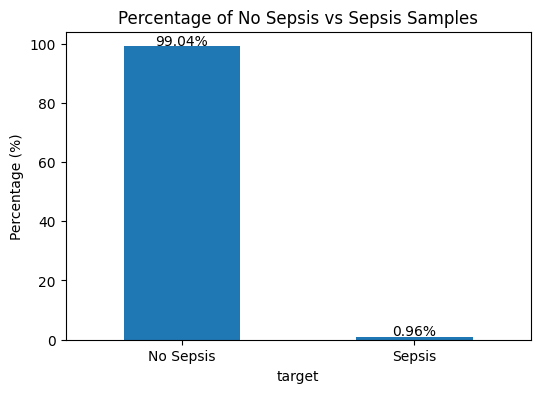

In [11]:
target_pct = data["target"].value_counts(normalize=True).sort_index() * 100
target_counts = data["target"].value_counts().sort_index()

summary_target = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct.round(2)
})
summary_target.index = ["No Sepsis", "Sepsis"]

display(summary_target)

# Class distribution plot

plt.figure(figsize=(6, 4))
ax = (data["target"].value_counts(normalize=True).sort_index() * 100).plot(kind="bar")
ax.set_xticklabels(["No Sepsis", "Sepsis"], rotation=0)
plt.ylabel("Percentage (%)")
plt.title("Percentage of No Sepsis vs Sepsis Samples")

for i, v in enumerate((data["target"].value_counts(normalize=True).sort_index() * 100).values):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha="center")

plt.show()

,cohort,target,percentage,target_label
0,A,0,98.804648,No Sepsis
1,A,1,1.195352,Sepsis
2,B,0,99.283674,No Sepsis
3,B,1,0.716326,Sepsis


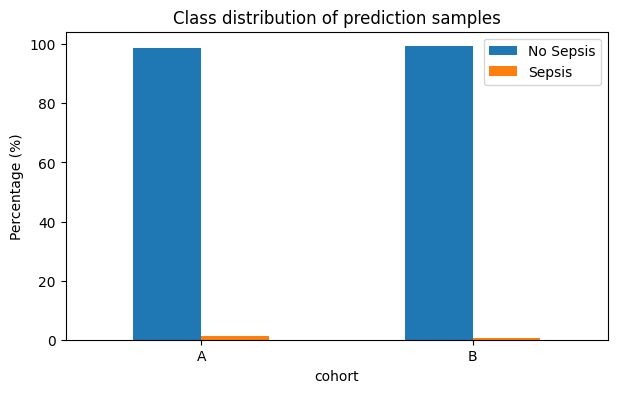

In [12]:
# Cohort specific percentages
cohort_target_pct = (
    data.groupby("cohort")["target"]
    .value_counts(normalize=True)
    .rename("percentage")
    .mul(100)
    .reset_index()
)

cohort_target_pct["target_label"] = cohort_target_pct["target"].map({0: "No Sepsis", 1: "Sepsis"})
display(cohort_target_pct)

pivot_cohort = cohort_target_pct.pivot(index="cohort", columns="target_label", values="percentage")

pivot_cohort.plot(kind="bar", figsize=(7, 4))
plt.ylabel("Percentage (%)")
plt.title("Class distribution of prediction samples")
plt.xticks(rotation=0)
plt.legend(title="")
plt.show()

Because each patient contributes multiple candidate prediction times, the temporal distribution of prediction points is inspected to understand how the engineered sample set is populated over the ICU stay.

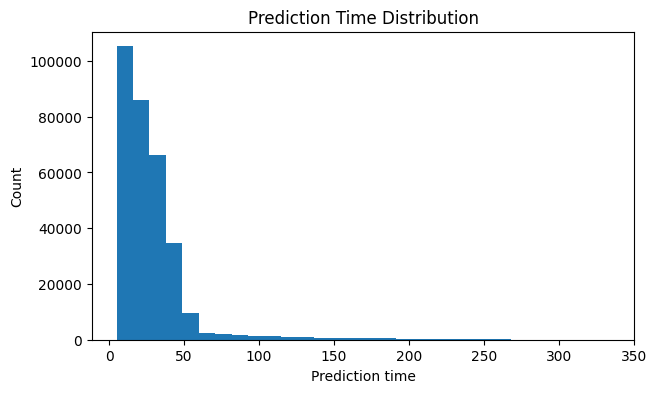

In [13]:
# Prediction time distribution

plt.figure(figsize=(7,4))
plt.hist(data["prediction_time"], bins=30)
plt.title("Prediction Time Distribution")
plt.xlabel("Prediction time")
plt.ylabel("Count")
plt.show()

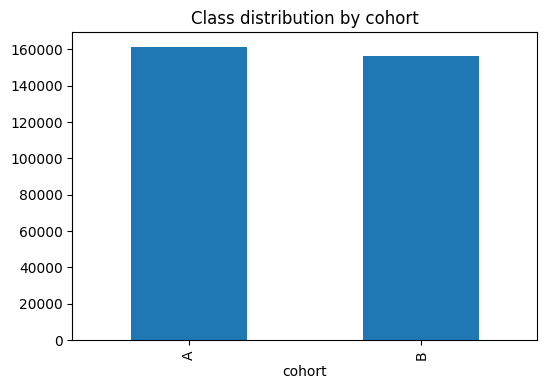

In [14]:
# Cohort distribution

plt.figure(figsize=(6,4))
data["cohort"].value_counts().plot(kind="bar")
plt.title("Class distribution by cohort")
plt.show()

### Class balance and missingness checks

In [15]:
feature_cols = [c for c in data.columns if c not in ["patient_id", "prediction_time", "target", "cohort"]]
missing_summary = data[feature_cols].isna().mean().sort_values(ascending=False)
missing_summary.head(20)



temp__Bilirubin_direct__slope    0.996766
temp__Bilirubin_direct__std      0.996766
temp__Bilirubin_direct__delta    0.996766
temp__Bilirubin_total__std       0.985727
temp__Bilirubin_total__slope     0.985727
temp__Bilirubin_total__delta     0.985727
temp__Bilirubin_direct__first    0.980788
temp__Bilirubin_direct__min      0.980788
temp__Bilirubin_direct__range    0.980788
temp__Bilirubin_direct__max      0.980788
temp__Bilirubin_direct__last     0.980788
temp__Bilirubin_direct__mean     0.980788
temp__TroponinI__delta           0.976166
temp__TroponinI__std             0.976166
temp__TroponinI__slope           0.976166
temp__Alkalinephos__slope        0.973458
temp__Alkalinephos__std          0.973458
temp__Alkalinephos__delta        0.973458
temp__AST__delta                 0.973313
temp__AST__std                   0.973313
dtype: float64

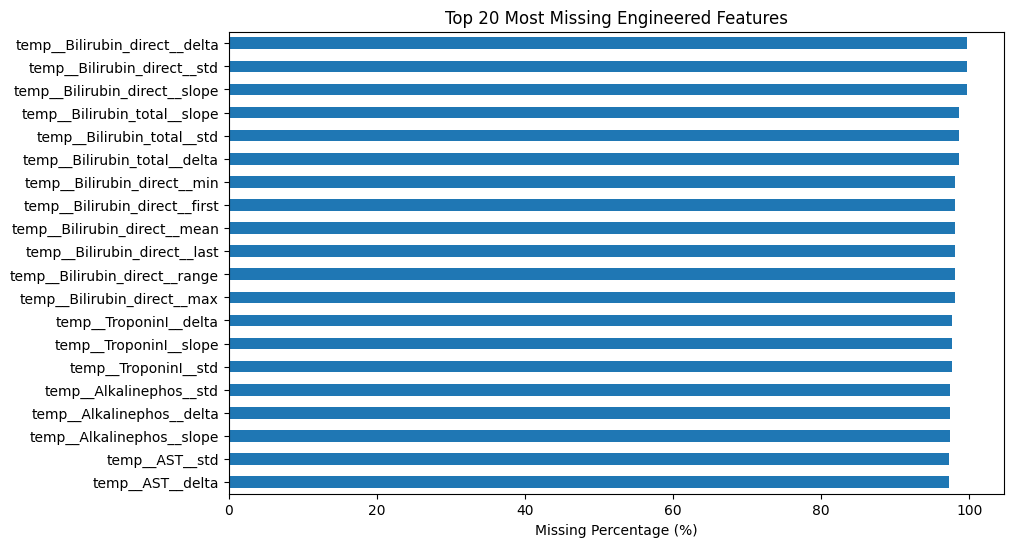

In [16]:
# Missingness heatmap

top_missing = (missing_summary.head(20) * 100).sort_values()

plt.figure(figsize=(10, 6))
top_missing.plot(kind="barh")
plt.xlabel("Missing Percentage (%)")
plt.title("Top 20 Most Missing Engineered Features")
plt.show()

Missingness is not only a technical limitation but also part of the clinical data-generating process. The feature design therefore retains missingness-related summaries, allowing the models to capture both physiological information and observation patterns.

In [17]:
MISSING_THRESHOLD = 0.60
keep_features = missing_summary[missing_summary < MISSING_THRESHOLD].index.tolist()

Extremely sparse engineered features are removed to reduce instability while preserving missingness-related signal in the remaining representation.

### Split strategy

To avoid information leakage, all splitting is performed at the patient level, ensuring that no patient contributes data to more than one evaluation partition.

In [18]:
# Split by patient_id
X = data[keep_features].copy()
y = data["target"].copy()
groups = data["patient_id"].copy()
cohort = data["cohort"].copy()

# Train/val/test split at patient level
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(gss1.split(X, y, groups=groups))

train_val_df = data.iloc[train_val_idx].copy()
test_df = data.iloc[test_idx].copy()

groups_train_val = train_val_df["patient_id"].copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, val_idx = next(
    gss2.split(
        train_val_df[keep_features],
        train_val_df["target"],
        groups=groups_train_val
    )
)

train_df = train_val_df.iloc[train_idx].copy()
val_df = train_val_df.iloc[val_idx].copy()

# Verify no patient overlap
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

print("Train/Val overlap:", len(train_patients & val_patients))
print("Train/Test overlap:", len(train_patients & test_patients))
print("Val/Test overlap:", len(val_patients & test_patients))

# Optional: training-only downsampling
if APPLY_DOWNSAMPLING:
    train_df = cluster_undersample(train_df, target_col="target", ratio=NEG_POS_RATIO)
    print("Applied undersampling to training set only.")

# Final matrices
X_train = train_df[keep_features].copy()
y_train = train_df["target"].copy()

X_val = val_df[keep_features].copy()
y_val = val_df["target"].copy()

X_test = test_df[keep_features].copy()
y_test = test_df["target"].copy()

Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0
  Downsampling: 201404 neg -> 18652 neg | 1893 pos | ratio=9.9:1
Applied undersampling to training set only.


## Preprocessing pipeline

A common preprocessing pipeline is used for simplicity and comparability across models.

In [19]:
numeric_features = X_train.columns.tolist()

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, numeric_features)
])

## Model Input Representation

Rather than feeding raw sequences directly into a recurrent neural network, this study uses a temporally summarized tabular representation. This choice is motivated by three considerations:

1. ICU measurements are highly irregular and sparse,
2. clinically meaningful explanations are easier to obtain from explicit temporal descriptors, and
3. feature-level reasoning can be compared more transparently across cohorts and model classes.

## Class Imbalance Handling

Sepsis events are rare in the engineered dataset, creating a severe class imbalance problem. The pipeline addresses this at multiple levels:

- Data level: optional majority-class undersampling is applied to the training split only.
- Model level: class-weighted learning is used where supported.
- Decision level: the classification threshold is selected on the validation set.
- Evaluation level: AUPRC is emphasized alongside AUROC and calibration.



## Model definitions

The model set is intentionally chosen to compare transparency and predictive flexibility. Logistic regression provides a highly inspectable baseline, while tree-based methods capture nonlinear interactions at the cost of less direct explanation mechanisms.

In [20]:
# Logistic regression
logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Random forest
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# HistGradientBoosting
hgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=300,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

## Evaluation helpers

Because early sepsis prediction is a highly imbalanced task, both discrimination and probability quality are assessed. In particular, AUPRC and calibration are emphasized alongside AUROC.

In [21]:
def compute_metrics(y_true, y_prob, threshold=0.5) -> Dict[str, float]:
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

# Threshold selection for validation
def find_best_threshold(y_true, y_prob, metric="f1"):
    thresholds = np.linspace(0.05, 0.95, 19)
    rows = []

    for thr in thresholds:
        m = compute_metrics(y_true, y_prob, threshold=thr)
        m["threshold"] = thr
        rows.append(m)

    df = pd.DataFrame(rows)
    best_thr = df.sort_values(metric, ascending=False).iloc[0]["threshold"]
    return best_thr, df

In [22]:
models = {
    "LogisticRegression": logreg,
    "RandomForest": rf,
    "HistGradientBoosting": hgb,
}

val_results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    val_prob = model.predict_proba(X_val)[:, 1]

    best_thr, thr_table = find_best_threshold(y_val, val_prob, metric="f1")
    metrics = compute_metrics(y_val, val_prob, threshold=best_thr)

    metrics["model"] = name
    metrics["best_threshold"] = best_thr
    val_results.append(metrics)
    fitted_models[name] = model

val_results_df = pd.DataFrame(val_results).sort_values("auprc", ascending=False)
val_results_df

,auroc,auprc,brier,precision,recall,f1,model,best_threshold
0,0.675012,0.030258,0.279284,0.057506,0.147228,0.082707,LogisticRegression,0.95
1,0.655738,0.017540,0.083818,0.030559,0.089866,0.045609,RandomForest,0.65
2,0.623819,0.016985,0.151875,0.022679,0.223709,0.041183,HistGradientBoosting,0.75


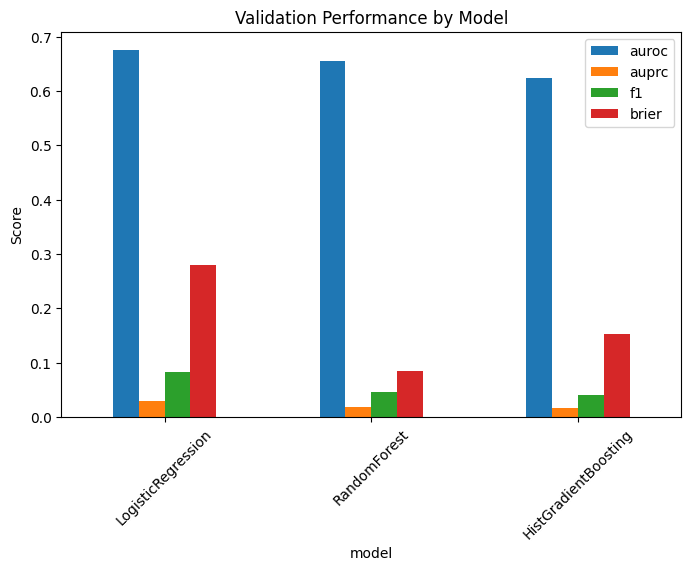

In [23]:
# Validation comparison plots

val_plot_df = val_results_df.set_index("model")[["auroc", "auprc", "f1", "brier"]]
val_plot_df.plot(kind="bar", figsize=(8,5))
plt.title("Validation Performance by Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

Validation performance is interpreted jointly with transparency and calibration. The goal is not only to maximize discrimination, but to understand whether gains in predictive performance come at the cost of explanation clarity or stability.

## Model selection for final evaluation

In [24]:
best_perf_model_name = val_results_df.sort_values("auprc", ascending=False).iloc[0]["model"]

interpretable_candidates = ["LogisticRegression"]
best_interp_model_name = (
    val_results_df[val_results_df["model"].isin(interpretable_candidates)]
    .sort_values("auprc", ascending=False)
    .iloc[0]["model"]
)

selected_models = list(dict.fromkeys([best_perf_model_name, best_interp_model_name]))

pd.DataFrame({
    "role": ["best_performing_model", "interpretable_reference_model"],
    "model": [best_perf_model_name, best_interp_model_name]
})

,role,model
0,best_performing_model,LogisticRegression
1,interpretable_reference_model,LogisticRegression


## Test evaluation

Final evaluation is reported on a held-out test set to distinguish model selection from final performance assessment.

### Test evaluation using validation-selected thresholds

In [25]:
final_rows = []

selected_models = list(dict.fromkeys([best_perf_model_name, best_interp_model_name]))

for name in selected_models:
    model = fitted_models[name]
    best_thr = val_results_df.loc[
        val_results_df["model"] == name,
        "best_threshold"
    ].iloc[0]

    test_prob = model.predict_proba(X_test)[:, 1]
    test_metrics = compute_metrics(y_test, test_prob, threshold=best_thr)

    test_metrics["model"] = name
    test_metrics["best_threshold"] = best_thr
    final_rows.append(test_metrics)

final_results_df = pd.DataFrame(final_rows)
final_results_df

,auroc,auprc,brier,precision,recall,f1,model,best_threshold
0,0.644477,0.018977,0.286321,0.034263,0.11041,0.052297,LogisticRegression,0.95


### Test-set confusion matrix

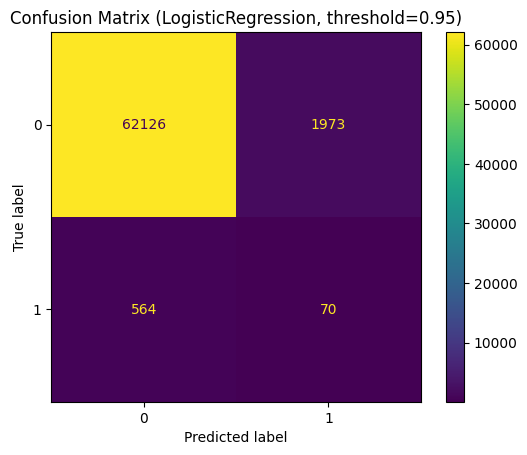

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = fitted_models[best_perf_model_name]
best_thr = val_results_df.loc[
    val_results_df["model"] == best_perf_model_name,
    "best_threshold"
].iloc[0]

test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_thr).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.title(f"Confusion Matrix ({best_perf_model_name}, threshold={best_thr:.2f})")
plt.show()

## Calibration and PR curves

Trustworthiness in a clinical prediction setting requires not only ranking patients correctly, but also producing probabilities that remain reasonably calibrated. Calibration analysis is therefore treated as a core evaluation component rather than a secondary diagnostic.

### Precision-Recall Curve

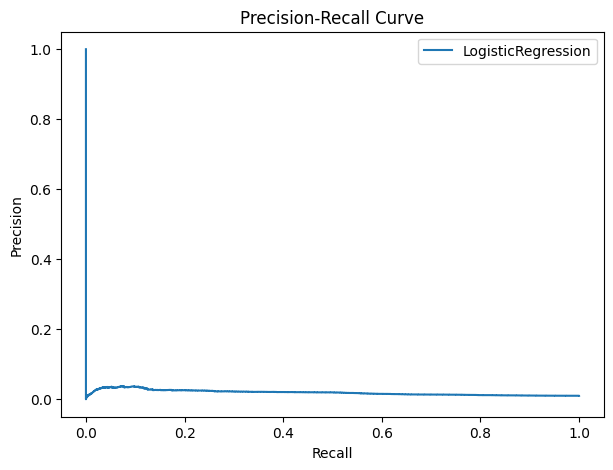

In [27]:
def plot_pr_curve(y_true, y_prob, label):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.plot(recall, precision, label=label)

plt.figure(figsize=(7, 5))
for name in selected_models:
    prob = fitted_models[name].predict_proba(X_test)[:, 1]
    plot_pr_curve(y_test, prob, name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

### Calibration Plot

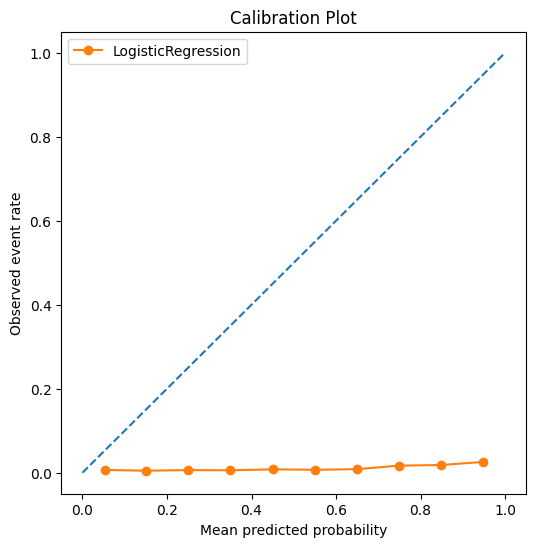

In [28]:
from sklearn.calibration import calibration_curve

def plot_calibration(y_true, y_prob, label):
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker="o", label=label)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "--")

for name in selected_models:
    prob = fitted_models[name].predict_proba(X_test)[:, 1]
    plot_calibration(y_test, prob, name)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event rate")
plt.title("Calibration Plot")
plt.legend()
plt.show()

## Interpretability

In this project, interpretability is understood as the ability to trace predictions back to clinically meaningful variables and temporal patterns. Beyond identifying important predictors, the analysis asks whether these explanations are plausible, understandable, and stable across settings.

Logistic regression serves here as both the highest-performing model in this run and the primary interpretable reference model.

### Logistic regression interpretation

Logistic regression serves as a transparent reference model because coefficient signs and magnitudes can be directly related to the engineered temporal descriptors.

In [29]:
logreg_model = fitted_models["LogisticRegression"]
coef_model = logreg_model.named_steps["model"]
feature_names = logreg_model.named_steps["preprocessor"].get_feature_names_out()

coefs = pd.DataFrame({
    "feature": feature_names,
    "coef": coef_model.coef_[0]
}).sort_values("coef", ascending=False)

coefs["abs_coef"] = coefs["coef"].abs()
coefs = coefs.sort_values("abs_coef", ascending=False)
coefs.head(20)

,feature,coef,abs_coef
57,num__temp__Hct__min,-3.408630,3.408630
44,num__temp__Hgb__max,3.053725,3.053725
60,num__temp__Potassium__min,-2.542568,2.542568
46,num__temp__Hgb__min,-2.487887,2.487887
54,num__temp__Hct__max,2.481334,2.481334
59,num__temp__Potassium__max,2.341115,2.341115
21,num__temp__WBC__min,-2.297871,2.297871
109,num__temp__Resp__max,2.239619,2.239619
25,num__temp__WBC__last,1.985551,1.985551
0,num__temp__Phosphate__first,-1.938279,1.938279


### SHAP-based explanation of the highest-performing model

SHAP analysis is used here not only to rank influential variables, but to investigate whether the model relies on clinically plausible physiological signal rather than artifacts of observation or workflow.

c:\Users\henry\Documents\Research\phD\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


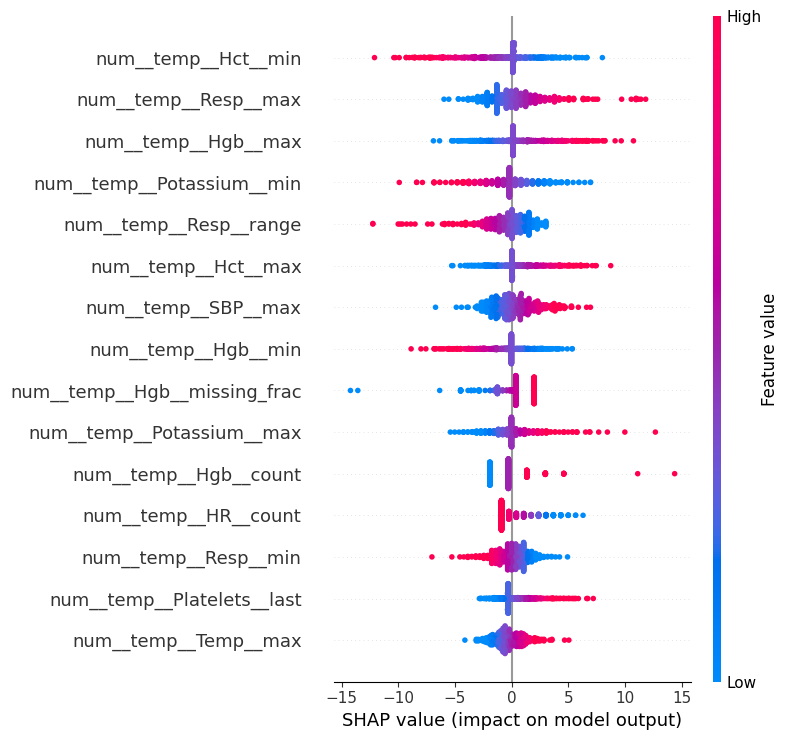

In [30]:
import shap
import numpy as np

# Best fitted pipeline
model = best_model.named_steps["model"]
preprocessor = best_model.named_steps["preprocessor"]

# Background data for LinearExplainer
X_train_transformed = preprocessor.transform(X_train)
X_sample = X_test.sample(min(500, len(X_test)), random_state=42)
X_transformed = preprocessor.transform(X_sample)

# Convert sparse matrices to dense if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

feature_names = preprocessor.get_feature_names_out()

# Choose explainer based on model type
if "LogisticRegression" in str(type(model)):
    explainer = shap.LinearExplainer(model, X_train_transformed)
    shap_values = explainer.shap_values(X_transformed)
else:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_transformed, check_additivity=False)

# For binary tree models that return a list
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    max_display=15
)

## Cohort robustness analysis

A trustworthy clinical model should not only maintain reasonable predictive performance across cohorts, but should also rely on broadly similar explanatory structure. This analysis therefore examines both performance transfer and the stability of important features across cohort-specific models.

### Cross-cohort explanation shift under transfer

In [31]:
# Merge cohorts
data_ab = pd.concat([dataset_a, dataset_b], ignore_index=True)

# Train on cohort A
X_train_ab = data_ab.loc[data_ab["cohort"] == "A", keep_features]
y_train_ab = data_ab.loc[data_ab["cohort"] == "A", "target"]

# Test on cohort B
X_test_ab = data_ab.loc[data_ab["cohort"] == "B", keep_features]
y_test_ab = data_ab.loc[data_ab["cohort"] == "B", "target"]

# Sample for speed
X_train_ab_sample = X_train_ab.sample(min(300, len(X_train_ab)), random_state=RANDOM_STATE)
X_test_ab_sample = X_test_ab.sample(min(300, len(X_test_ab)), random_state=RANDOM_STATE)

rf_model_ab = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model_ab.fit(X_train_ab, y_train_ab)

X_train_a_transformed = rf_model_ab.named_steps["preprocessor"].transform(X_train_ab_sample)
X_test_b_transformed = rf_model_ab.named_steps["preprocessor"].transform(X_test_ab_sample)

if hasattr(X_train_a_transformed, "toarray"):
    X_train_a_transformed = X_train_a_transformed.toarray()
if hasattr(X_test_b_transformed, "toarray"):
    X_test_b_transformed = X_test_b_transformed.toarray()

explainer_ab = shap.TreeExplainer(rf_model_ab.named_steps["model"])

shap_a = explainer_ab.shap_values(X_train_a_transformed, check_additivity=False)
shap_b = explainer_ab.shap_values(X_test_b_transformed, check_additivity=False)

def get_positive_class_mean_abs(shap_values):
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap_values = np.array(shap_values)

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    if shap_values.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")

    return np.abs(shap_values).mean(axis=0)

mean_abs_a = get_positive_class_mean_abs(shap_a)
mean_abs_b = get_positive_class_mean_abs(shap_b)

feature_names_ab = rf_model_ab.named_steps["preprocessor"].get_feature_names_out()

shap_comp = pd.DataFrame({
    "feature": feature_names_ab,
    "train_A": mean_abs_a,
    "test_B": mean_abs_b
})

shap_comp["shift"] = (shap_comp["test_B"] - shap_comp["train_A"]).abs()
shap_comp = shap_comp.sort_values("shift", ascending=False)

shap_comp.head(20)

,feature,train_A,test_B,shift
144,num__temp__DBP__count,0.948158,0.628342,0.319816
130,num__temp__HR__range,0.658457,0.378521,0.279935
142,num__temp__FiO2__count,1.068817,1.298224,0.229406
67,num__temp__DBP__delta,0.873695,0.716289,0.157405
61,num__temp__Potassium__mean,0.177080,0.026407,0.150673
199,num__temp__O2Sat__missing_frac,0.087343,0.215538,0.128196
102,num__temp__MAP__std,0.807023,0.928453,0.121430
87,num__temp__SBP__range,0.167495,0.054985,0.112510
126,num__temp__O2Sat__max,0.881215,0.988647,0.107432
129,num__temp__HR__min,0.375797,0.268530,0.107267


### Cohort-specific feature importance comparison

In [32]:
rf_a = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_b = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

X_a = data_ab.loc[data_ab["cohort"] == "A", keep_features]
y_a = data_ab.loc[data_ab["cohort"] == "A", "target"]

X_b = data_ab.loc[data_ab["cohort"] == "B", keep_features]
y_b = data_ab.loc[data_ab["cohort"] == "B", "target"]

rf_a.fit(X_a, y_a)
rf_b.fit(X_b, y_b)

imp_a = rf_a.named_steps["model"].feature_importances_
imp_b = rf_b.named_steps["model"].feature_importances_

feature_names_a = rf_a.named_steps["preprocessor"].get_feature_names_out()
feature_names_b = rf_b.named_steps["preprocessor"].get_feature_names_out()
assert np.array_equal(feature_names_a, feature_names_b)

imp_comp = pd.DataFrame({
    "feature": feature_names_a,
    "importance_A": imp_a,
    "importance_B": imp_b
})

imp_comp["shift"] = (imp_comp["importance_B"] - imp_comp["importance_A"]).abs()
imp_comp = imp_comp.sort_values("shift", ascending=False)

display(imp_comp.head(20))

,feature,importance_A,importance_B,shift
141,num__temp__FiO2__missing_frac,0.025428,0.001782,0.023646
142,num__temp__FiO2__count,0.021977,0.001591,0.020385
156,num__temp__EtCO2__missing_frac,0.000000,0.017298,0.017298
154,num__temp__EtCO2__count,0.000000,0.015176,0.015176
107,num__temp__Resp__min,0.018152,0.008244,0.009908
95,num__temp__Temp__first,0.009054,0.018268,0.009214
134,num__static__HospAdmTime,0.013017,0.019716,0.006699
40,num__static__Unit1,0.008620,0.002100,0.006521
196,num__temp__SBP__missing_frac,0.008630,0.003083,0.005547
6,num__temp__Glucose__std,0.002278,0.007511,0.005233


## Failure analysis

Failure analysis helps identify whether misclassifications arise from weak physiological signal, sparse observation patterns, or cohort-specific variation, and therefore supports a more trustworthy interpretation of the model’s limitations.

### Error profile of the highest-performing model

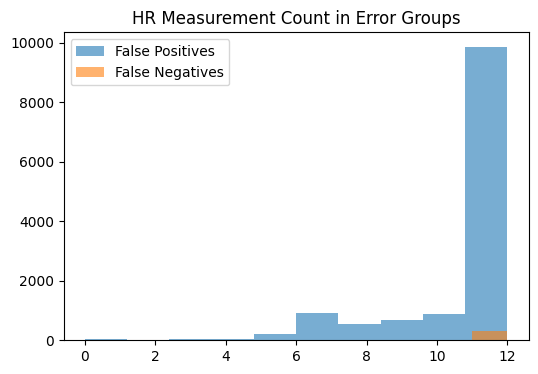

In [33]:
best_model = fitted_models[best_perf_model_name]
best_thr = val_results_df.loc[
    val_results_df["model"] == best_perf_model_name,
    "best_threshold"
].iloc[0]

test_prob = best_model.predict_proba(X_test)[:, 1]

error_df = X_test.copy()
error_df["y_true"] = y_test.values
error_df["y_prob"] = test_prob
error_df["y_pred"] = (test_prob >= best_thr).astype(int)

false_pos = error_df[(error_df["y_true"] == 0) & (error_df["y_pred"] == 1)]
false_neg = error_df[(error_df["y_true"] == 1) & (error_df["y_pred"] == 0)]

pd.DataFrame({
    "error_type": ["false_positives", "false_negatives"],
    "count": [len(false_pos), len(false_neg)]
})

# Comparison Plot 

if "temp__HR__count" in error_df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(false_pos["temp__HR__count"].dropna(), alpha=0.6, label="False Positives")
    plt.hist(false_neg["temp__HR__count"].dropna(), alpha=0.6, label="False Negatives")
    plt.legend()
    plt.title("HR Measurement Count in Error Groups")
    plt.show()

### Bootstrap confidence intervals

To avoid over-interpreting point estimates, performance metrics are complemented with bootstrap confidence intervals, providing a more reliable view of uncertainty in model evaluation.

In [34]:
def bootstrap_metrics(y_true, y_prob, threshold=0.5, n_boot=500, random_state=42):
    """Bootstrap 95% CIs for AUROC, AUPRC, Brier, and F1."""
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    records = {m: [] for m in ["auroc", "auprc", "brier", "f1"]}

    for _ in range(n_boot):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        yt, yp = y_true[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        yhat = (yp >= threshold).astype(int)
        records["auroc"].append(roc_auc_score(yt, yp))
        records["auprc"].append(average_precision_score(yt, yp))
        records["brier"].append(brier_score_loss(yt, yp))
        records["f1"].append(f1_score(yt, yhat, zero_division=0))

    results = {}
    for m, vals in records.items():
        lo, med, hi = np.percentile(vals, [2.5, 50, 97.5])
        results[m] = {"median": med, "ci_lo": lo, "ci_hi": hi}
    return results

best_model = fitted_models[best_perf_model_name]
test_prob = best_model.predict_proba(X_test)[:, 1]
best_thr = val_results_df.loc[
    val_results_df["model"] == best_perf_model_name,
    "best_threshold"
].iloc[0]

ci = bootstrap_metrics(y_test, test_prob, threshold=best_thr, n_boot=500)

ci_df = pd.DataFrame(ci).T
ci_df.index.name = "metric"
ci_df["summary"] = ci_df.apply(
    lambda r: f"{r['median']:.4f} ({r['ci_lo']:.4f} – {r['ci_hi']:.4f})", axis=1
)
ci_df[["summary"]]

,summary
metric,
auroc,0.6308 (0.6108 – 0.6534)
auprc,0.0180 (0.0156 – 0.0207)
brier,0.4065 (0.4038 – 0.4098)
f1,0.0341 (0.0300 – 0.0384)


## Conclusion

This project demonstrates that early sepsis prediction can be approached using a leakage-aware temporal feature engineering pipeline that transforms irregular ICU trajectories into clinically interpretable descriptors.

Across models, Logistic Regression achieved the best overall performance while maintaining full interpretability, highlighting that simple models can remain competitive when paired with strong feature engineering.

Beyond predictive performance, the analysis emphasized:
- the importance of calibration in highly imbalanced clinical tasks,
- the role of missingness as a clinically meaningful signal,
- and the need for robustness across cohorts.

Cohort transfer experiments showed that while predictive performance remains relatively stable, feature importance can shift, reinforcing the need for careful validation when deploying models across settings.

Overall, the pipeline balances performance, interpretability, and robustness, supporting a more trustworthy application of machine learning in clinical decision support.